# Testing different stretch factors to create more robust training for our model

In [1]:
import torch
import pyvista as pv
import numpy as np
from torch_geometric.data import Data
from torch_geometric.transforms import Compose
from sklearn.decomposition import PCA
from transformations import CanonicalAlignment, RobustCanonicalAlignment 
from transformations import LocalDentalStretch, MultiPointDentalStretch, AnatomicalDentalStretch, RandomizedDentalBandStretch
from transformations import RandomBlobRemoval
from transformations import MolarBandExpansion, IncisalArchExpansion, JawShear, InterMolarGapStretch

/opt/anaconda3/envs/Dental/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def visualize_transforms(ply_path):
    # 1. Load original mesh
    mesh = pv.read(ply_path)
    
    # 2. Extract colors
    color_name = None
    for potential_name in ['colors', 'RGB', 'RGBA', 'vertex_colors']:
        if potential_name in mesh.point_data:
            color_name = potential_name
            break
    colors_np = mesh.point_data[color_name] if color_name else None

    # 3. Create Data object
    data = Data(
        pos=torch.from_numpy(mesh.points).float(),
        colors=torch.from_numpy(colors_np) if colors_np is not None else None
    )
    
    # 4. Run Transforms
    # Both views should be aligned so they are in the same spot!
    alignment = RobustCanonicalAlignment()
    before_data = alignment.forward(data.clone())
    
    pipeline = Compose([
        RobustCanonicalAlignment(),
        MolarBandExpansion(),
        IncisalArchExpansion(),
        JawShear(),
        InterMolarGapStretch()
    ])
    after_data = pipeline(data)
    
    # 5. Helper for Plotting
    def to_pv_cloud(data_obj):
        cloud = pv.PolyData(data_obj.pos.numpy())
        if hasattr(data_obj, 'colors') and data_obj.colors is not None:
            cloud.point_data['display_colors'] = data_obj.colors.numpy()
        return cloud

    # We want a SURFACE for the "Before" view to get those nice shadows
    before_surface = mesh.copy()
    before_surface.points = before_data.pos.numpy()
    
    after_cloud = to_pv_cloud(after_data)

    # 6. Plotting
    plotter = pv.Plotter(shape=(1, 2))
    
    # Subplot 1: Aligned Surface (WITH SHADOWS)
    plotter.subplot(0, 0)
    plotter.add_text("Aligned Base", font_size=12)
    plotter.add_mesh(before_surface, scalars=color_name, rgb=True if color_name else False)
    
    # Subplot 2: The Hole (POINT CLOUD)
    plotter.subplot(0, 1)
    plotter.add_text("Hole Removal", font_size=12)
    plotter.add_mesh(
        after_cloud, 
        scalars='display_colors', 
        rgb=True if color_name else False,
        render_points_as_spheres=True,
        point_size=2.0, # Reduced size to stop the "bumpy" look
        lighting=True
    )
    
    plotter.link_views()
    
    # Focus and Zoom
    plotter.subplot(0, 0)
    plotter.view_isometric()
    plotter.reset_camera() # This now works because both models are at (0,0,0)
    plotter.camera.zoom(1.2)
    
    plotter.show()

/var/folders/1g/bksky7bd2wb927qzgc2fqjhc0000gn/T/ipykernel_67977/4002249583.py:74: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


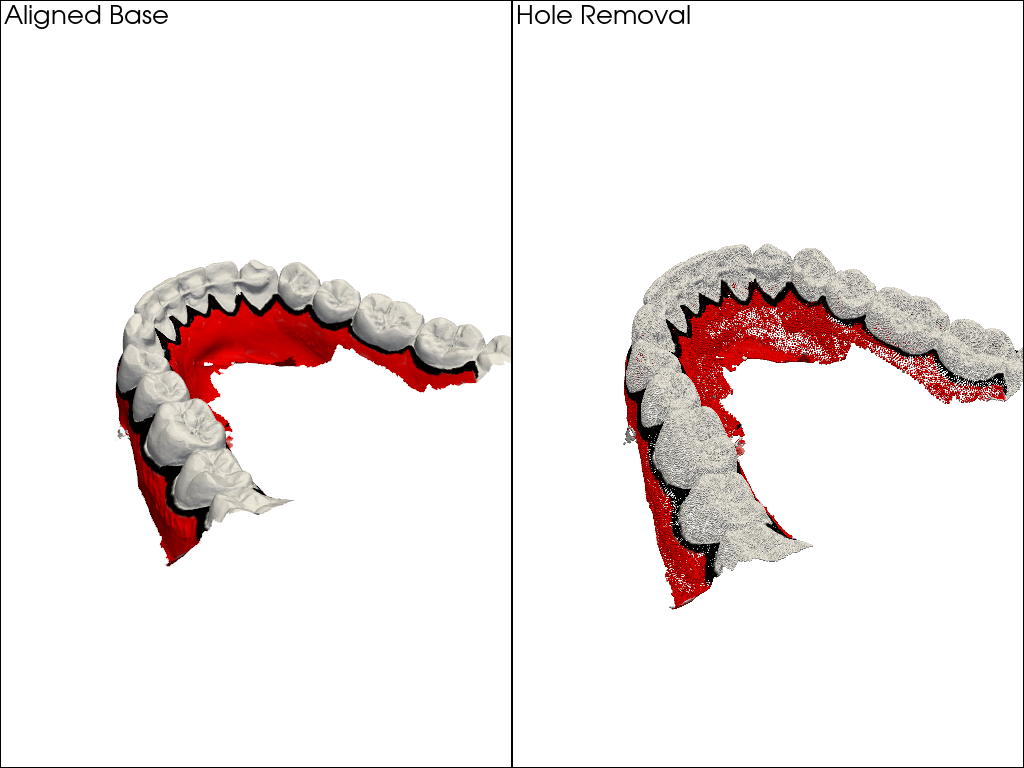

In [55]:
visualize_transforms("../data/labeled/01_c.ply")

In [5]:
visualize_transforms("../data/ODC3F7X8_lower.ply")

FileNotFoundError: File (/Users/peeyushpatel/Desktop/projects/Dental-detection/data/ODC3F7X8_lower.ply) not found

In [ ]:
import torch
import pyvista as pv
import numpy as np
import os
import meshio
from torch_cluster import knn
from model import DentalMetricDGCNN
from config import config
from data_loader import DentalDataset

def visualize_high_res_prediction(file_idx=0):
    device = torch.device("cpu")
    
    # 1. Load Model and Predict (Keep this part the same)
    model = DentalMetricDGCNN(k=config.K_NEIGHBORS, num_classes=config.NUM_CLASSES, 
                              embed_dim=config.GLOBAL_EMBED_DIM // 8)
    checkpoint = torch.load(os.path.join(config.CHECKPOINT_DIR, "best_model.pth"), map_location=device)
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()

    raw_dataset = DentalDataset(root=config.DATA_DIR)
    raw_data = raw_dataset.get(file_idx)
    
    # Standard alignment and prediction
    from transformations import RobustCanonicalAlignment
    from torch_geometric.transforms import Compose, FixedPoints, NormalizeScale
    processed_data = RobustCanonicalAlignment()(raw_data.clone())
    low_res_data = Compose([FixedPoints(8192), NormalizeScale()])(processed_data.clone())
    
    with torch.no_grad():
        logits = model(low_res_data)
        low_res_preds = torch.argmax(logits, dim=1)

    # 2. KNN Upsampling
    assign_idx = knn(low_res_data.pos, processed_data.pos, k=1)
    high_res_preds = low_res_preds[assign_idx[1]].numpy()

    # 3. Use Meshio for the Final Save (Strict PLY formatting)
    # Get the original mesh points and faces
    file_path = os.path.join(config.DATA_DIR, raw_dataset.files[file_idx])
    original_pv_mesh = pv.read(file_path)
    
    points = original_pv_mesh.points
    # PyVista faces are [n, i1, i2, i3, n, i1...], meshio wants [N, 3]
    faces = original_pv_mesh.faces.reshape(-1, 4)[:, 1:]

    # Define standard RGB colors
    colors = np.zeros((len(points), 3), dtype=np.uint8)
    colors[high_res_preds == 0] = [255, 0, 0]     # Red
    colors[high_res_preds == 1] = [0, 0, 0]       # Black
    colors[high_res_preds == 2] = [255, 255, 255] # White

    # Create the meshio object
    mesh = meshio.Mesh(
        points,
        [("triangle", faces)],
        point_data={
            "red": colors[:, 0],
            "green": colors[:, 1],
            "blue": colors[:, 2],
            "label": high_res_preds.astype(np.float32) # Backup: visible in MeshLab Quality Mapper
        }
    )

    output_path = "high_res_final.ply"
    mesh.write(output_path)
    print(f"--- Hard-coded PLY saved to {output_path} ---")

if __name__ == "__main__":
    visualize_high_res_prediction(file_idx=0)